
# Neural Networks Playground (PyTorch)

This notebook is the **PyTorch equivalent** of the TensorFlow Playground, before running the code, make sure you understand this interactive demo:

https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.47151&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false

**Goal:**  
PyTorch implementation of the Playground:
1. dataset  
2. neural network architecture  
3. loss function  
4. An optimizer  

We will build **the same thing in PyTorch**, step by step.



## Learning objectives

By the end of this notebook, you should understand:

- What a neural network **architecture** is
- What a **loss function** does
- What an **optimizer** does
- How decision boundaries emerge from training
- How this relates to **representation** and **bias–variance tradeoff**


In [35]:

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np



## Step 1 — Choose a dataset

Just like TensorFlow Playground, we use **simple 2D datasets** so we can
*see* what the network is learning.

**Change the parameters below and re-run the notebook**


In [38]:

# ============================
# STUDENT PARAMETERS (DATA)
# ============================

dataset_choice = "moons"  # options: "moons", "circles", "classification"
n_samples = 5000
noise = 0.05


In [ ]:

if dataset_choice == "moons":
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)
elif dataset_choice == "circles":
    X, y = make_circles(n_samples=n_samples, noise=noise, factor=0.5, random_state=42)
else:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=42
    )

plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", s=5)
plt.title("Raw dataset")
plt.show()



## Step 2 — Preprocessing

Neural networks are sensitive to scale.

We **standardize** the data so each feature has:
- mean = 0
- standard deviation = 1

Important:  
The model will learn in this **scaled feature space**.


In [41]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test_t  = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)



## Step 3 — Define the neural network architecture

This corresponds to **networkShape** in TensorFlow Playground.

Change:
- number of layers
- number of neurons
- activation function


In [105]:

# ============================
# STUDENT PARAMETERS (MODEL)
# ============================

hidden_sizes = [5, 5]        # neurons per hidden layer
activation_choice = "tanh"  # "tanh", "relu", "sigmoid"
dropout_rate = 0.0

def make_model(activation_choice, hidden_sizes, dropout_rate):
    
    activations = {
        "tanh": nn.Tanh(),
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid()
    }

    activation_fn = activations[activation_choice]

    layers = []
    input_size = X_train.shape[1]

    for h in hidden_sizes:
        layers.append(nn.Linear(input_size, h))
        layers.append(activation_fn)
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        input_size = h

    # Output layer (binary classification)
    layers.append(nn.Linear(input_size, 1))

    model = nn.Sequential(*layers)
    return model


In [108]:
model= make_model(activation_choice, hidden_sizes, dropout_rate)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Tanh()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): Tanh()
  (4): Linear(in_features=5, out_features=1, bias=True)
)



## Step 4 — Loss function and optimizer

**Overall training loop logic:**

1. Define a loss function (what is a "mistake"?)
2. Define an optimizer (how do we update weights?)

The optimization is the process that we use the data to train the model, learning rate controls how fast we allow the optimzer to move, and number of epochs how |long. 

There are limitations:

- Training cost grows with number of epochs. 
- We cannot make learning rate too large, just like driving, the solver may crash if it moves too fast. 

In [144]:

# ============================
# STUDENT PARAMETERS (TRAINING)
# ============================


learning_rate = 0.01
epochs = 250
weight_decay = 0.0

model= make_model(activation_choice, hidden_sizes, dropout_rate)  # why do we repeat this line here again? (what happens if you remove it?)


criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)


3. Repeatedly:
   - predict
   - compute loss
   - backpropagate
   - update parameters

In [145]:

train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_t)
        val_loss = criterion(val_logits, y_test_t)
        val_losses.append(val_loss.item())


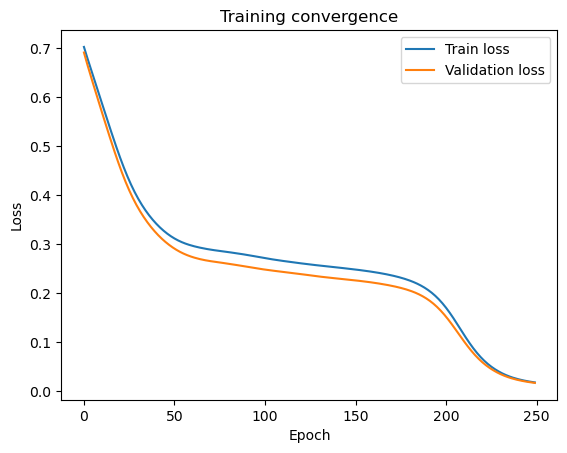

In [146]:

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training convergence")
plt.show()



## Step 5 — Decision boundary

This is the **neural network equivalent** of the decision boundaries
you saw in the Iris decision tree notebook.

The boundary lives in **feature space**.


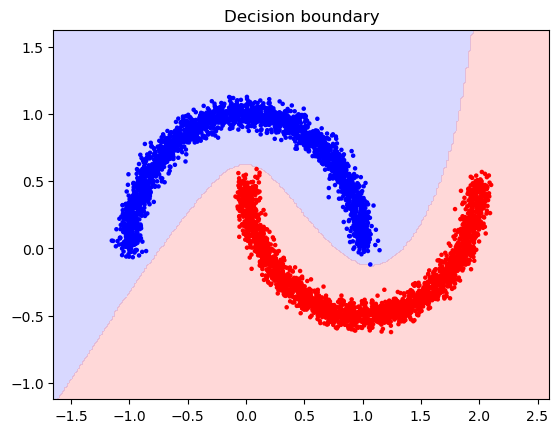

In [147]:

def plot_decision_boundary(model, X_raw, y, scaler):
    x_min, x_max = X_raw[:,0].min()-0.5, X_raw[:,0].max()+0.5
    y_min, y_max = X_raw[:,1].min()-0.5, X_raw[:,1].max()+0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_raw)
    grid_t = torch.tensor(grid_scaled, dtype=torch.float32)

    with torch.no_grad():
        logits = model(grid_t)
        probs = torch.sigmoid(logits).reshape(xx.shape)

    plt.contourf(xx, yy, probs > 0.5, alpha=0.3, cmap="bwr")
    plt.scatter(X_raw[:,0], X_raw[:,1], c=y, cmap="bwr", s=5)
    plt.title("Decision boundary")
    plt.show()

plot_decision_boundary(model, X, y, scaler)


To do:

- Try out a small learning rate `learning_rate = 0.001` and a few iteration `epochs= 75`, note the train and test error and the decision boundary. 
- Now fix this by better choices of number of epoches and learning rates:
  - First keep the learning rate the same `learning_rate = 0.001`, but only change the number of `epochs= 500`. 
  - Then change both `learning_rate = 0.01` and `epochs = 500`
    Can you explain these different choices?

- Now try out a large learning rate, how fast can the solver go before becoming unstable? Note that the end solution maybe OK even when we have an unstable path, because the problem is not too hard! 